# Обедающие философы: базовые эксперименты

Задача об обедающих философах моделируется сетью Петри. Позиции сети
--- состояния философов (думает, голоден, ест) и вилки. Переходы ---
действия: взять левую вилку, взять правую вилку, положить вилки.

Сравним два варианта сети:

- классическую, в которой возможна взаимная блокировка (deadlock);
- сеть с арбитром, который разрешает брать вилки не более чем
  $N - 1$ философам одновременно.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("DiningPhilosophers.jl"))
using .DiningPhilosophers
using DataFrames, CSV, Plots, Random

## Параметры

Пять философов, время моделирования 50 единиц. Зерно генератора
фиксируем, чтобы результат повторялся.

In [2]:
N = 5
tmax = 50.0
seed = 42

42

## Классическая сеть: стохастическое моделирование

Используется алгоритм Гиллеспи: на каждом шаге случайно выбирается
один из разрешённых переходов и время до его срабатывания.

In [3]:
println("=== Классическая сеть (без арбитра) ===")
net_classic, u0_classic, _ = build_classical_network(N)
df_classic = simulate_stochastic(net_classic, u0_classic, tmax; rng = Xoshiro(seed))
CSV.write(datadir("dining_classic.csv"), df_classic)
dead = detect_deadlock(df_classic, net_classic)
println("Deadlock обнаружен: $dead")
println("Число событий: ", nrow(df_classic) - 1)
println("Время последнего события: ", round(df_classic.time[end], digits = 2))

=== Классическая сеть (без арбитра) ===
Deadlock обнаружен: true
Число событий: 8
Время последнего события: 1.8


Эволюция маркировки по группам позиций:

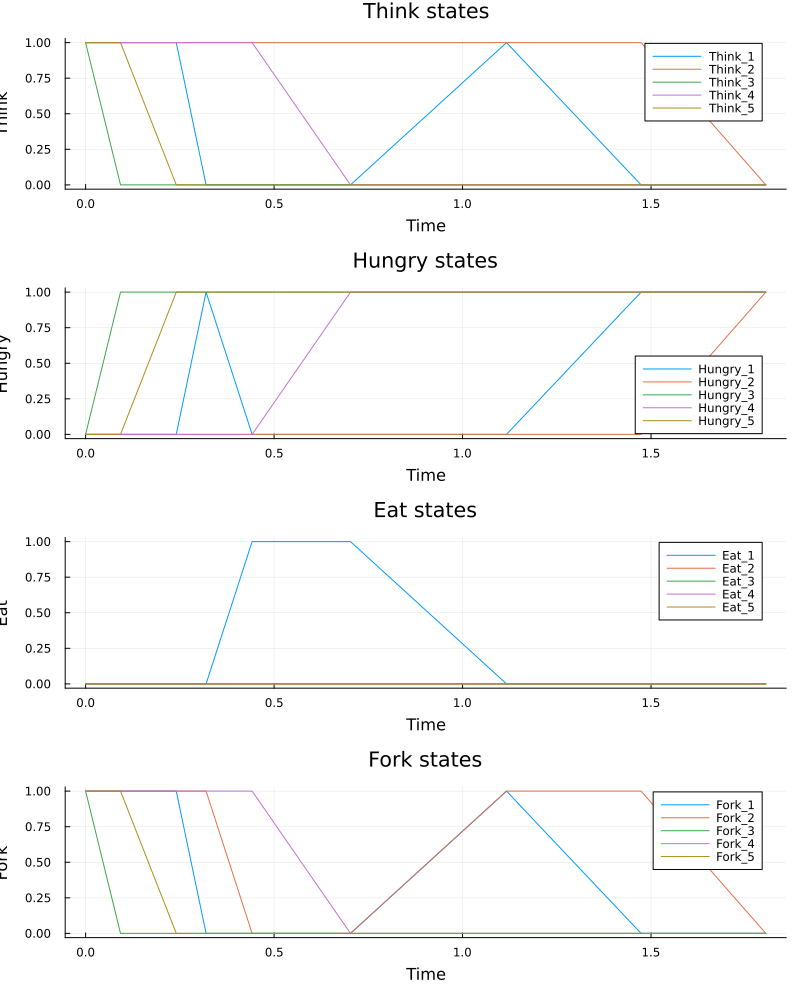

In [4]:
plot_classic = plot_marking_evolution(df_classic, N)
savefig(plot_classic, plotsdir("classic_simulation.png"))
plot_classic

## Сеть с арбитром: стохастическое моделирование

Добавлена позиция `Arbiter` с $N - 1$ фишками. Фишка забирается, когда
философ берёт левую вилку, и возвращается, когда он кладёт вилки.

In [5]:
println("=== Сеть с арбитром ===")
net_arb, u0_arb, _ = build_arbiter_network(N)
df_arb = simulate_stochastic(net_arb, u0_arb, tmax; rng = Xoshiro(seed))
CSV.write(datadir("dining_arbiter.csv"), df_arb)
dead_arb = detect_deadlock(df_arb, net_arb)
println("Deadlock обнаружен: $dead_arb")
println("Число событий: ", nrow(df_arb) - 1)
println("Время последнего события: ", round(df_arb.time[end], digits = 2))

=== Сеть с арбитром ===
Deadlock обнаружен: false
Число событий: 77
Время последнего события: 49.56


Эволюция маркировки:

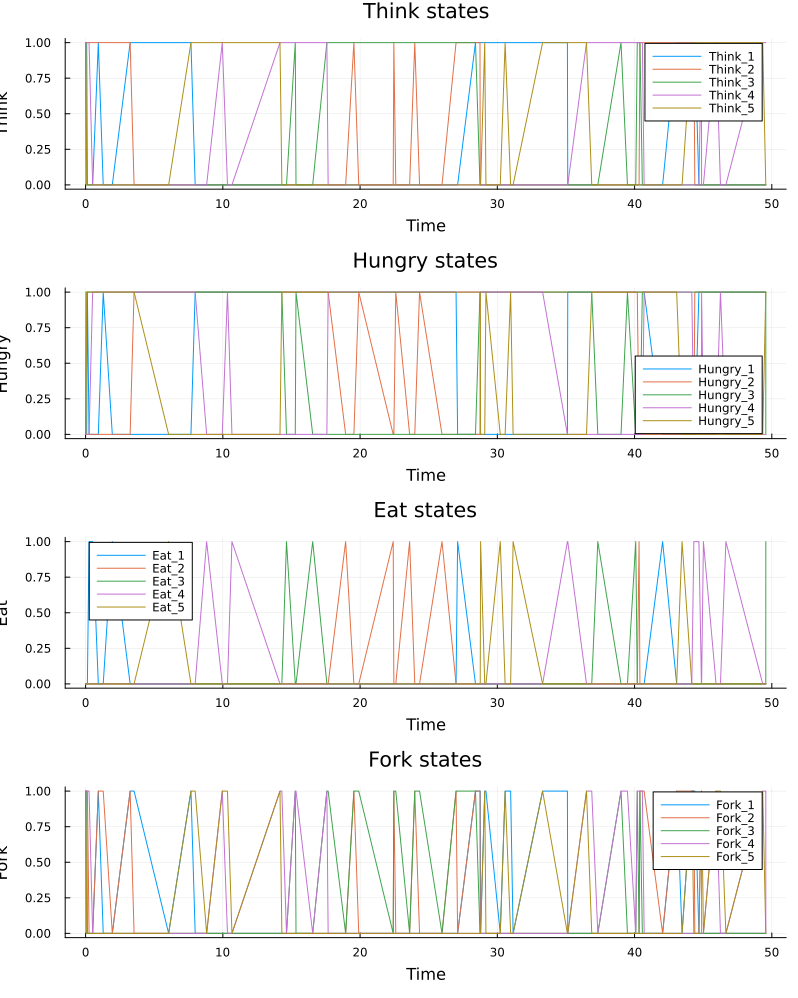

In [6]:
plot_arb = plot_marking_evolution(df_arb, N)
savefig(plot_arb, plotsdir("arbiter_simulation.png"))
plot_arb

## Классическая сеть: детерминированное моделирование

Ту же сеть можно описать системой обыкновенных дифференциальных
уравнений. Число фишек тогда становится непрерывной величиной.

In [7]:
df_ode = simulate_ode(net_classic, u0_classic, tmax)
CSV.write(datadir("dining_classic_ode.csv"), df_ode)
println("=== Классическая сеть, ODE ===")
println("Think_1 в конце: ", round(df_ode[end, "Think_1"], digits = 3))
println("Hungry_1 в конце: ", round(df_ode[end, "Hungry_1"], digits = 3))
println("Eat_1 в конце: ", round(df_ode[end, "Eat_1"], digits = 3))
println("Fork_1 в конце: ", round(df_ode[end, "Fork_1"], digits = 3))

=== Классическая сеть, ODE ===
Think_1 в конце: 0.434
Hungry_1 в конце: 0.434
Eat_1 в конце: 0.131
Fork_1 в конце: 0.303


Эволюция маркировки в непрерывной модели:

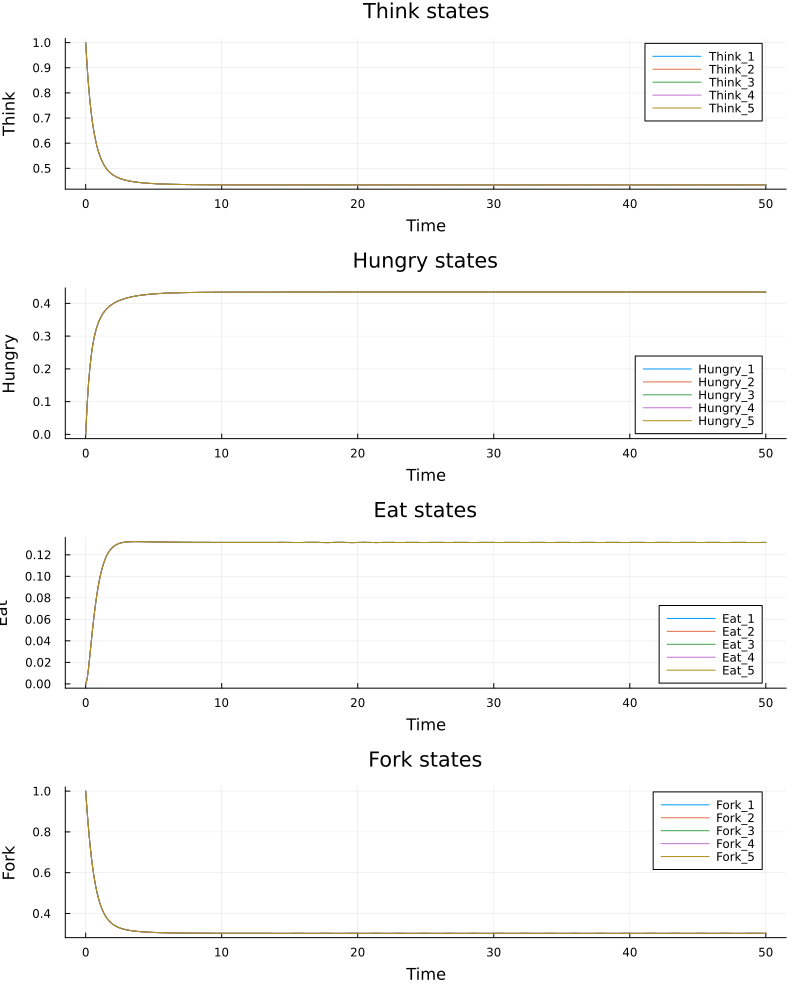

In [8]:
plot_ode = plot_marking_evolution(df_ode, N)
savefig(plot_ode, plotsdir("classic_ode.png"))
plot_ode